# P2 - RNNs

**Authors**:
- Pablo Diaz 
- Daniel Prieto

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Preprocessing of the data

Load the data from the CSV file.

In [2]:
df = pd.read_csv("data/nyiso_hourly_load.csv")
df.head()

,Time Stamp,CAPITL,CENTRL,DUNWOD,GENESE,HUD VL,LONGIL,MHK VL,MILLWD,N.Y.C.,NORTH,WEST,total_load
0,2021-01-01 05:00:00+00:00,1229.765829,1652.064229,601.434650,980.770850,1001.962714,2061.066821,841.068829,319.410071,4808.552936,635.814164,1525.174400,15657.085493
1,2021-01-01 06:00:00+00:00,1199.764783,1606.512858,579.089583,934.267075,960.858267,1946.459783,807.607275,307.969050,4631.978808,633.340358,1473.827217,15081.675058
2,2021-01-01 07:00:00+00:00,1172.361075,1578.671450,559.861700,913.383017,936.291717,1855.849567,796.252242,301.264983,4486.644667,617.937925,1435.501408,14654.019750
3,2021-01-01 08:00:00+00:00,1164.461967,1556.862842,548.799792,901.166967,916.932750,1797.270625,794.205750,295.269642,4372.209042,615.713533,1417.398217,14380.291125
4,2021-01-01 09:00:00+00:00,1177.303475,1561.628092,545.171408,898.999517,915.355317,1791.221000,798.552250,295.507442,4336.574433,615.466042,1419.729483,14355.508458


In [3]:
print(df.columns)

Index(['Time Stamp', 'CAPITL', 'CENTRL', 'DUNWOD', 'GENESE', 'HUD VL',
       'LONGIL', 'MHK VL', 'MILLWD', 'N.Y.C.', 'NORTH', 'WEST', 'total_load'],
      dtype='str')


Create a temporal split, since the data is time series data, we cannot do a random split. We will use the following splits: 

- Training set: 2021–2023
- Validation set: 2024
- Test set: 2025

In [4]:
# split the data into training/validation/test sets

# Training Set 2021 to 2023
train_df = df[df["Time Stamp"] < "2024-01-01"]
print(len(train_df))

# Validation Set 2024
val_df = df[(df["Time Stamp"] >= "2024-01-01") & (df["Time Stamp"] < "2025-01-01")]
print(len(val_df))

# Test Set 2025
test_df = df[df["Time Stamp"] >= "2025-01-01"]
print(len(test_df))

# drop the "Time Stamp" column
train_df = train_df.drop(columns=["Time Stamp"])
val_df = val_df.drop(columns=["Time Stamp"])
test_df = test_df.drop(columns=["Time Stamp"])

26107
8784
8765


Now we start the preparation of the data that will be fed to the models. First we are going to standardize the data, using pandas utility functions on dataframes. We start by getting the mean and standard deviation of the training set and then we can apply the standardization to the training, validation and test sets. It is done this way to avoid data leakage, since we will be using just the training set to train the models, it it only fair to use just the training set to compute the mean and standard deviation.

In [6]:
mean = train_df.mean()
std = train_df.std()

print(f"Mean:\n{mean}\n")
print(f"Standard Deviation:\n{std}\n")

Mean:
CAPITL         1327.515791
CENTRL         1736.799880
DUNWOD          646.373512
GENESE         1087.183369
HUD VL         1051.645915
LONGIL         2276.543855
MHK VL          837.988563
MILLWD          322.531092
N.Y.C.         5593.559854
NORTH           646.981059
WEST           1676.361131
total_load    17203.484021
dtype: float64

Standard Deviation:
CAPITL         233.315696
CENTRL         272.144257
DUNWOD         146.049529
GENESE         189.547436
HUD VL         232.391308
LONGIL         634.965917
MHK VL         159.596627
MILLWD          76.722991
N.Y.C.        1148.912783
NORTH           65.901310
WEST           224.922815
total_load    3085.204590
dtype: float64



In [7]:
train_df_scaled = (train_df - mean) / std
val_df_scaled = (val_df - mean) / std
test_df_scaled = (test_df - mean) / std

At this point the data is standardized, but we still need to prepare the data in a way that can be fed to the recurrent models. We need to create sequences of data that will be fed to the models. For this point we tried different sequence lengths with the base RNN model, to find which sequence length worked best at first. We started with a sequence length of 168 (7 days) since we had hypothesized that the weekly patterns would be of interest. However, after some experimentation, we found that shorther sequences worked better, and the best sequence length was 24 hours.

In [ ]:
from keras.utils import timeseries_dataset_from_array

# sequences of 168 hours (1 week) to predict total load 3 hours ahead
sequence_length = 24

batch_size = 64
sample_rate = 1  # hourly data, so one sample per hour
delay = sample_rate * (sequence_length + 3 - 1)  # 3 hours in the future

train_ds = timeseries_dataset_from_array(
    data=train_df_scaled.values,
    targets=train_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
    shuffle=True,
)

val_ds = timeseries_dataset_from_array(
    data=val_df_scaled.values,
    targets=val_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

test_ds = timeseries_dataset_from_array(
    data=test_df_scaled.values,
    targets=test_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

In [9]:
epochs = 30

### Utils functions

#### Plot

In [10]:
import matplotlib.pyplot as plt


def plot_mae(history, std=1.0):
    loss = [v * std for v in history.history["mae"]]
    val_loss = [v * std for v in history.history["val_mae"]]
    epochs = range(1, len(loss) + 1)
    plt.figure()
    plt.plot(epochs, loss, "b-o", label="Training MAE")
    plt.plot(epochs, val_loss, "r--o", label="Validation MAE")
    plt.title("Training and validation MAE")
    plt.ylabel("MAE (MW)")
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()

## Baselines

### Last Value Baseline

A last value baseline is a simple model that just predicts the last value of the sequence as the next value. This is a really simple model but it can be a good baseline to compare the models. 

In [11]:
mean_total = mean["total_load"]
std_total = std["total_load"]


def evaluate_baseline(dataset, get_pred_fn):
    total_abs_error = 0
    samples_counter = 0
    for samples, targets in dataset:
        preds = get_pred_fn(samples) * std_total + mean_total
        tgts = targets * std_total + mean_total
        total_abs_error += np.sum(np.abs(preds - tgts))
        samples_counter += samples.shape[0]
    return total_abs_error / samples_counter


# last observed total_load value (position -1 in window, feature -1 = total_load)
last_value_fn = lambda samples: samples[:, -1, -1]

print(f"Last Value — Validation MAE: {evaluate_baseline(val_ds, last_value_fn):.2f}")
print(f"Last Value — Test MAE:       {evaluate_baseline(test_ds, last_value_fn):.2f}")

Last Value — Validation MAE: 1402.25
Last Value — Test MAE:       1399.68


### Last Day Baseline

A last day baseline is a simple model that just predicts the value of the same hour of the previous day as the next value. This is a really simple model as well, but it could be useful to compare the models since the data might have strong daily patterns.

In [12]:
# Target is 3h after the last element (pos 167), so 24h before target is pos 167+3-24 = 146
daily_fn = lambda samples: samples[:, 146, -1]

print(f"Daily Baseline — Validation MAE: {evaluate_baseline(val_ds, daily_fn):.2f}")
print(f"Daily Baseline — Test MAE:       {evaluate_baseline(test_ds, daily_fn):.2f}")

W0000 00:00:1777919593.621603  236119 op_kernel.cc:1858] OP_REQUIRES failed at strided_slice_op.cc:117 : INVALID_ARGUMENT: slice index 146 of dimension 1 out of bounds.
W0000 00:00:1777919593.621853  236119 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: slice index 146 of dimension 1 out of bounds.


InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:CPU:0}} slice index 146 of dimension 1 out of bounds. [Op:StridedSlice] name: strided_slice/

### Neural Baseline (Conv1D + Dense)

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2068 - mae: 0.2718 - val_loss: 0.2081 - val_mae: 0.3391
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0525 - mae: 0.1718 - val_loss: 0.0514 - val_mae: 0.1756
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0396 - mae: 0.1498 - val_loss: 0.0887 - val_mae: 0.2257
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0326 - mae: 0.1356 - val_loss: 0.0480 - val_mae: 0.1687
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0275 - mae: 0.1254 - val_loss: 0.0415 - val_mae: 0.1582
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0244 - mae: 0.1177 - val_loss: 0.0356 - val_mae: 0.1409
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0216 - mae: 0.1117 - val_loss: 0.0419 - val_mae: 0.1523
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0198 - mae: 0.1068 - val_loss: 0.0516 - val_mae: 0.1742
Epoch 9/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - lo

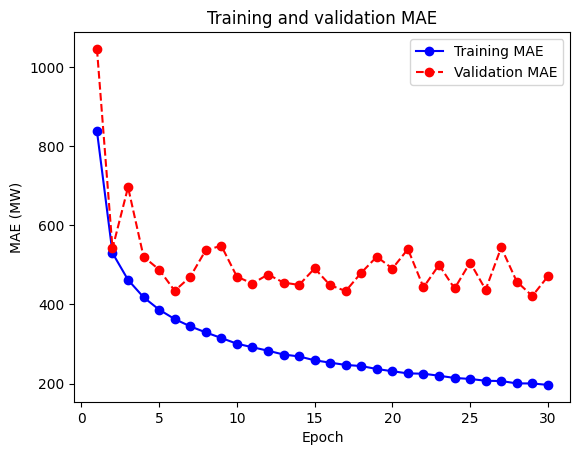

In [ ]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.Conv1D(64, 5, activation="relu", padding="causal")(inputs)
x = layers.Conv1D(32, 3, activation="relu", padding="causal")(x)
x = layers.Flatten()(x)  # keeps all temporal info
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1)(x)
model_conv = keras.Model(inputs, outputs)

callbacks = [keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True),
             keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
model_conv.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_conv = model_conv.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

model_conv = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model_conv.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_conv, std=std_total)

## Part 2: Recurrent Models

For each model type we start with a base configuration (1 recurrent layer + 1 dense and no regularization) and then explore:
- **Recurrent dropout** — applying a fixed dropout mask to recurrent activations (Gal & Ghahramani, 2016).
- **Stacked layers** — increasing model depth using `return_sequences=True` on the first layer.

All models use `rmsprop` optimizer and `batch_size=64` to keep comparisons fair.

### SimpleRNN

#### Base model

As mentioned before, a lot of configurations were explored for the SimpleRNN, mainly to see what configuration of the preprocessing step (sequence length) worked best, as well as architectural changes (regularization, recurrent dropout). We started testing the models with a sequence length of 168 (7 days) since we had hypothesized that the weekly patterns would be of interest. However, after some experimentation, we found that a sequence of 24 hours worked better. This might be because of the vanishing gradient problem that SimpleRNNs have, which makes it difficult for the model to learn long-term dependencies.

For the archictecture, we use 128 units, in earlier experiments we found that the model benefited from having more units. A Dense(32) hidden layer is added between the recurrent output and the final output layer.

In [17]:
from typing import cast

import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.SimpleRNN(128)(inputs)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_rnn_128.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5),
]

optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)

model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

history_simple_rnn = model.fit(
    train_ds, epochs=70, validation_data=val_ds, callbacks=callbacks
)

model = keras.models.load_model("jena_rnn_128.keras")
model = cast(keras.Model, model)

print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

Epoch 1/70
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0553 - mae: 0.1667 - val_loss: 0.0309 - val_mae: 0.1363 - learning_rate: 0.0010
Epoch 2/70
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0241 - mae: 0.1195 - val_loss: 0.0277 - val_mae: 0.1299 - learning_rate: 0.0010
Epoch 3/70
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0208 - mae: 0.1107 - val_loss: 0.0273 - val_mae: 0.1287 - learning_rate: 0.0010
Epoch 4/70
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0192 - mae: 0.1059 - val_loss: 0.0304 - val_mae: 0.1327 - learning_rate: 0.0010
Epoch 5/70
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0177 - mae: 0.1016 - val_loss: 0.0238 - val_mae: 0.1166 - learning_rate: 0.0010
Epoch 6/70
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0172 - mae: 0.0998 - val_loss: 0.0225 - val_mae: 0.1133 - learning_rate: 0.0010
Epoch 7/70
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0159 - mae: 0.0960 - val_loss: 0.0230 - val_mae: 0.1134 - learning_rate: 0.0010
Epoch 

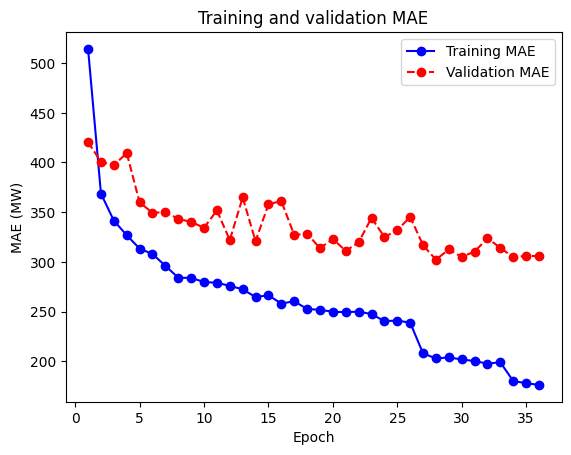

In [18]:
plot_mae(history_simple_rnn, std=std_total)

We can see in the graph above that the model converges quite fast. Also there is a gap between the two curves by the end of training the model fits the training set better than the validation set, indicating some overfitting. 

This model is already much better than the non-learned baselines. This demonstrates that even a simple recurrent model can learn useful patterns in the data and make better predictions than simple heuristics like the last value or the last day baselines.

In terms of raw numbers, the model obtains a validation MAE of 0.0991 (not scaled) and in the test set it obtains a MAE 387.77 (scaled). This is a pretty good result, consideting how simple the model is, and a good starting point to explore more complex configurations.

#### SimpleRNN with recurrent dropout

We can see on the graph above that the base model is kind of overfitting, the difference between the training and validation errors is quite susbtantial, as well as the the loss which is minimal on the training but not on the validation set. We are going to try to apply recurrent dropout and a dropout layer. To compensate for the regularization we are going to increase the number of units to 256, since we have seen that the model can benefit from more capacity.

Epoch 1/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.1011 - mae: 0.2386 - val_loss: 0.0672 - val_mae: 0.2094 - learning_rate: 0.0010
Epoch 2/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0578 - mae: 0.1858 - val_loss: 0.0365 - val_mae: 0.1484 - learning_rate: 0.0010
Epoch 3/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0490 - mae: 0.1704 - val_loss: 0.0330 - val_mae: 0.1396 - learning_rate: 0.0010
Epoch 4/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0435 - mae: 0.1597 - val_loss: 0.0369 - val_mae: 0.1497 - learning_rate: 0.0010
Epoch 5/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0403 - mae: 0.1546 - val_loss: 0.0256 - val_mae: 0.1209 - learning_rate: 0.0010
Epoch 6/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0400 - mae: 0.1531 - val_loss: 0.0269 - val_mae: 0.1248 - learning_rate: 0.0010
Epoch 7/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0386 - mae: 0.1504 - val_loss: 0.0287 - val_mae: 0.1280 - learning_rate:

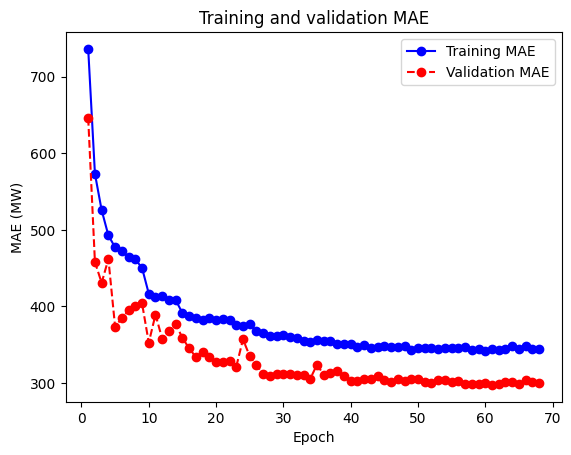

In [22]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.SimpleRNN(256, recurrent_dropout=0.1)(inputs)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_rnn_dropout.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5, verbose=1),
]

optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)

model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
history_rnn_dropout = model.fit(
    train_ds, epochs=100, validation_data=val_ds, callbacks=callbacks
)

model = keras.models.load_model("jena_rnn_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_rnn_dropout, std=std_total)

The training curves show something interesting, the validation MAE is below the training MAE always. This does not mean that there is data leakage or something is wrong, but a consequence of the regularization caused by the dropout and recurrent dropout. 

In the end, the model is performs quite similar to the base model. The test MAE is very similar to the base model. This could mean that the overfitting saw in the base model was not really a problem, and that the regularization did not really help the model to generalize better.

Therefore, in this case, the regularization did not really help the model to generalize better, and the base model is already good enough for this problem.

### LSTM

#### Base model

In [ ]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(64)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5),
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_lstm = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1053 - mae: 0.2376 - val_loss: 0.0594 - val_mae: 0.1910
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0351 - mae: 0.1446 - val_loss: 0.0470 - val_mae: 0.1670
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0290 - mae: 0.1299 - val_loss: 0.0388 - val_mae: 0.1491
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0262 - mae: 0.1223 - val_loss: 0.0324 - val_mae: 0.1356
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0226 - mae: 0.1133 - val_loss: 0.0319 - val_mae: 0.1347
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0211 - mae: 0.1093 - val_loss: 0.0330 - val_mae: 0.1385
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0189 - mae: 0.1041 - val_loss: 0.0311 - val_mae: 0.1329
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0178 - mae: 0.1007 - val_loss: 0.0323 - val_mae: 0.1383
Epoch 9/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/

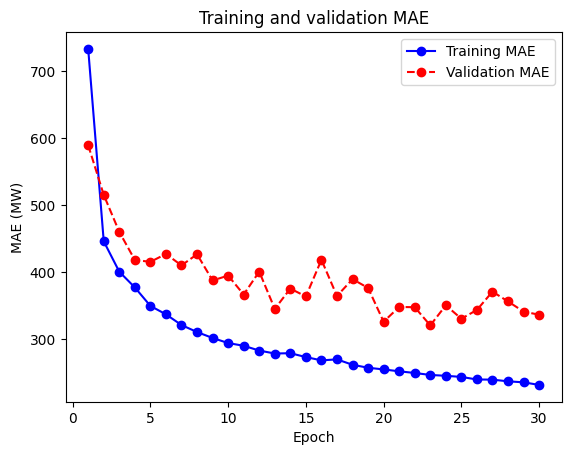

In [17]:
plot_mae(history_lstm, std=std_total)

#### LSTM with recurrent dropout

We apply the same regularization strategy as with SimpleRNN: `recurrent_dropout=0.25` on the LSTM and `Dropout(0.5)` on its output, with 32 units and 20 training epochs.

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 235s 575ms/step - loss: 0.2180 - mae: 0.3629 - val_loss: 0.0838 - val_mae: 0.2277
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 226s 556ms/step - loss: 0.1151 - mae: 0.2662 - val_loss: 0.0588 - val_mae: 0.1885
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 224s 551ms/step - loss: 0.0932 - mae: 0.2377 - val_loss: 0.0491 - val_mae: 0.1704
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 226s 556ms/step - loss: 0.0840 - mae: 0.2248 - val_loss: 0.0440 - val_mae: 0.1600
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 224s 553ms/step - loss: 0.0816 - mae: 0.2189 - val_loss: 0.0400 - val_mae: 0.1526
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 224s 552ms/step - loss: 0.0767 - mae: 0.2129 - val_loss: 0.0378 - val_mae: 0.1483
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 224s 552ms/step - loss: 0.0823 - mae: 0.2167 - val_loss: 0.0388 - val_mae: 0.1506
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 222s 546ms/step - loss: 0.0724 - mae: 0.2060 - val_loss: 0.0377 - val_mae: 0.1477
Epoch 9/30
406/406 ━━━━━

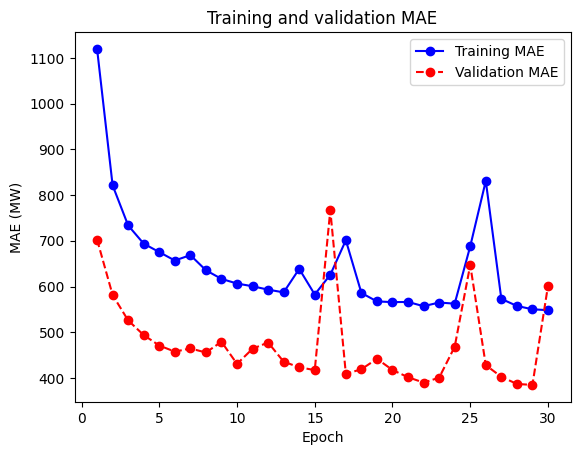

In [ ]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(64, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5),
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_lstm_dropout = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_lstm_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_lstm_dropout, std=std_total)

#### Stacked LSTM

To increase model capacity we stack two LSTM layers. The first must use `return_sequences=True` to pass the full output sequence to the second. We use stronger dropout (`recurrent_dropout=0.5`) to compensate for the additional capacity, and train for 30 epochs.

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 480s 1s/step - loss: 0.2693 - mae: 0.4033 - val_loss: 0.1203 - val_mae: 0.2698
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 477s 1s/step - loss: 0.1334 - mae: 0.2846 - val_loss: 0.0833 - val_mae: 0.2260
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 482s 1s/step - loss: 0.1034 - mae: 0.2485 - val_loss: 0.0665 - val_mae: 0.2019
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 481s 1s/step - loss: 0.0928 - mae: 0.2335 - val_loss: 0.0796 - val_mae: 0.2170
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 477s 1s/step - loss: 0.0828 - mae: 0.2212 - val_loss: 0.0592 - val_mae: 0.1895
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 477s 1s/step - loss: 0.0783 - mae: 0.2145 - val_loss: 0.0502 - val_mae: 0.1708
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 476s 1s/step - loss: 0.0723 - mae: 0.2054 - val_loss: 0.0482 - val_mae: 0.1656
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 479s 1s/step - loss: 0.0680 - mae: 0.1990 - val_loss: 0.0664 - val_mae: 0.1917
Epoch 9/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 475s 1s/

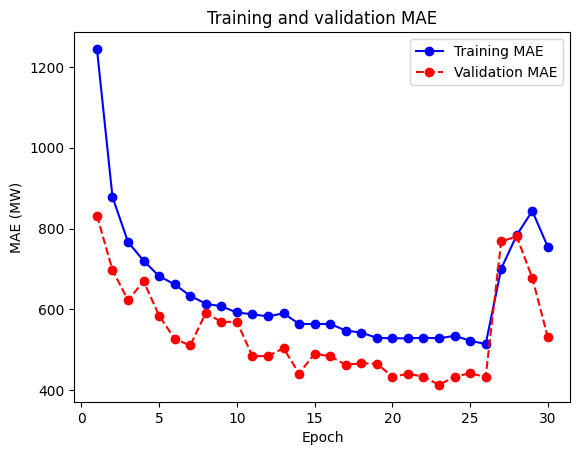

In [ ]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(64, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.LSTM(64, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm_stacked.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5),
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_lstm_stacked = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_lstm_stacked.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_lstm_stacked, std=std_total)

### GRU

#### Base model

In [ ]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(128)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [keras.callbacks.ModelCheckpoint("jena_gru.keras", save_best_only=True),
             keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
             keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5)]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_gru = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

model = keras.models.load_model("jena_gru.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 33s 79ms/step - loss: 0.0806 - mae: 0.2138 - val_loss: 0.0470 - val_mae: 0.1679
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - loss: 0.0325 - mae: 0.1397 - val_loss: 0.0328 - val_mae: 0.1421
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 30s 73ms/step - loss: 0.0256 - mae: 0.1234 - val_loss: 0.0420 - val_mae: 0.1529
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 31s 76ms/step - loss: 0.0226 - mae: 0.1148 - val_loss: 0.0289 - val_mae: 0.1330
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 31s 75ms/step - loss: 0.0205 - mae: 0.1092 - val_loss: 0.0303 - val_mae: 0.1320
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - loss: 0.0188 - mae: 0.1046 - val_loss: 0.0239 - val_mae: 0.1182
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - loss: 0.0180 - mae: 0.1019 - val_loss: 0.0286 - val_mae: 0.1277
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 33s 82ms/step - loss: 0.0172 - mae: 0.0995 - val_loss: 0.0269 - val_mae: 0.1215
Epoch 9/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 

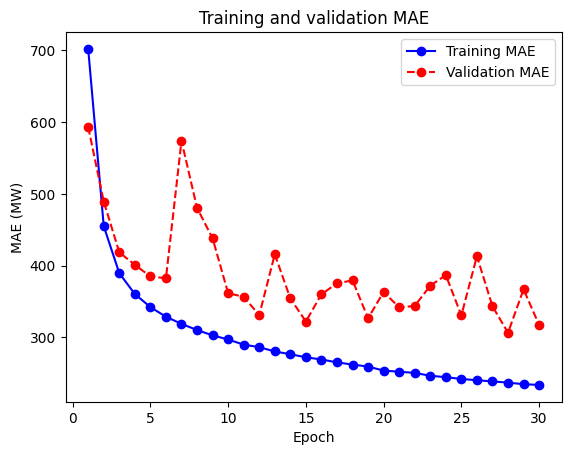

In [21]:
plot_mae(history_gru, std=std_total)

#### GRU with recurrent dropout

Same regularization as LSTM: `recurrent_dropout=0.25`, `Dropout(0.5)`, 32 units, 20 epochs. GRU has fewer parameters than LSTM so it trains faster.

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 0.1755 - mae: 0.3192 - val_loss: 0.0908 - val_mae: 0.2317
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - loss: 0.0849 - mae: 0.2286 - val_loss: 0.0535 - val_mae: 0.1798
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 0.0694 - mae: 0.2061 - val_loss: 0.0476 - val_mae: 0.1688
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 0.0613 - mae: 0.1934 - val_loss: 0.0367 - val_mae: 0.1484
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - loss: 0.0559 - mae: 0.1850 - val_loss: 0.0404 - val_mae: 0.1578
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 0.0520 - mae: 0.1782 - val_loss: 0.0338 - val_mae: 0.1427
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - loss: 0.0491 - mae: 0.1723 - val_loss: 0.0375 - val_mae: 0.1513
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - loss: 0.0469 - mae: 0.1690 - val_loss: 0.0457 - val_mae: 0.1650
Epoch 9/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 

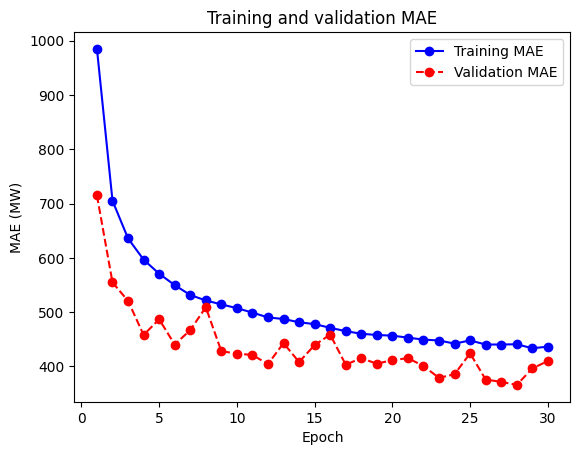

In [ ]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(64, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_gru_dropout.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5),
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_gru_dropout = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

model = keras.models.load_model("jena_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_gru_dropout, std=std_total)

#### Stacked GRU

Two stacked GRU layers with strong dropout regularization (`recurrent_dropout=0.5`) and 30 training epochs, following the same pattern as stacked LSTM.

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 494s 1s/step - loss: 0.2165 - mae: 0.3591 - val_loss: 0.0852 - val_mae: 0.2308
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 462s 1s/step - loss: 0.1204 - mae: 0.2708 - val_loss: 0.0552 - val_mae: 0.1806
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 474s 1s/step - loss: 0.0987 - mae: 0.2441 - val_loss: 0.0474 - val_mae: 0.1695
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 493s 1s/step - loss: 0.0901 - mae: 0.2324 - val_loss: 0.0525 - val_mae: 0.1797
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - loss: 0.0826 - mae: 0.2228 - val_loss: 0.0470 - val_mae: 0.1737
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 480s 1s/step - loss: 0.0775 - mae: 0.2151 - val_loss: 0.0447 - val_mae: 0.1646
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 504s 1s/step - loss: 0.0721 - mae: 0.2063 - val_loss: 0.0521 - val_mae: 0.1772
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 525s 1s/step - loss: 0.0688 - mae: 0.2020 - val_loss: 0.0430 - val_mae: 0.1608
Epoch 9/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 519s 1s/

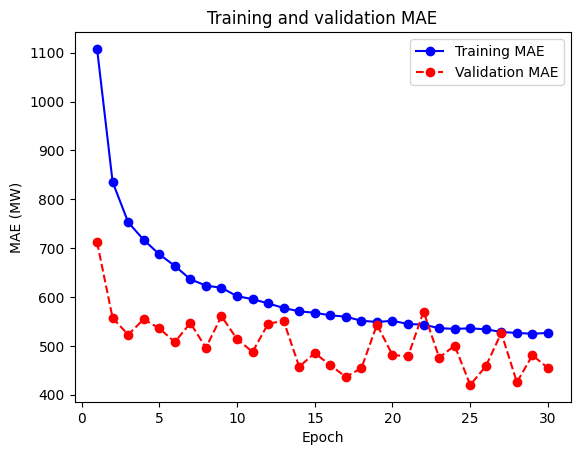

In [ ]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(64, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(64, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_gru_stacked.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5),
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_gru_stacked = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_gru_stacked.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_gru_stacked, std=std_total)

## Analysis and Comparison

We collect all test MAEs (denormalized, in MW) and display them in a single table and bar chart.

                         Model  Test MAE (MW)
           Last Value Baseline        1401.42
                Daily Baseline        1007.14
        Conv1D Neural Baseline        1920.46
          SimpleRNN (16 units)         466.60
SimpleRNN + Dropout (32 units)         693.98
               LSTM (16 units)         430.14
     LSTM + Dropout (32 units)         494.65
           LSTM Stacked (32×2)         510.24
                GRU (16 units)         393.43
      GRU + Dropout (32 units)         472.99
            GRU Stacked (32×2)         504.97


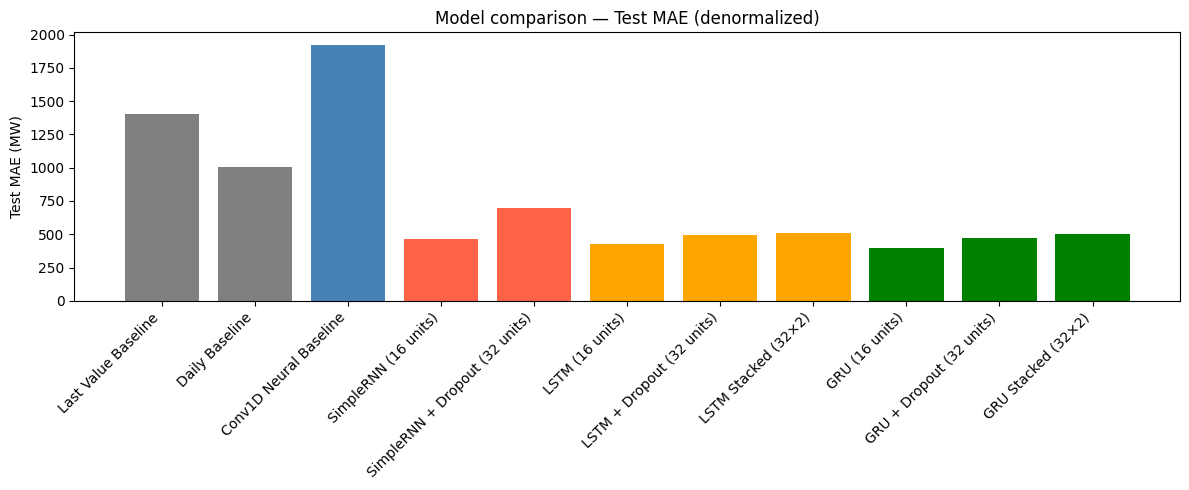

In [24]:
import pandas as pd

def get_test_mae(model_path):
    m = keras.models.load_model(model_path)
    return m.evaluate(test_ds, verbose=0)[1] * std_total

model_names = [
    "Last Value Baseline",
    "Daily Baseline",
    "Conv1D Neural Baseline",
    "SimpleRNN (16 units)",
    "SimpleRNN + Dropout (32 units)",
    "LSTM (16 units)",
    "LSTM + Dropout (32 units)",
    "LSTM Stacked (32×2)",
    "GRU (16 units)",
    "GRU + Dropout (32 units)",
    "GRU Stacked (32×2)",
]

test_maes = [
    evaluate_baseline(test_ds, last_value_fn),
    evaluate_baseline(test_ds, daily_fn),
    get_test_mae("jena_conv.keras"),
    get_test_mae("jena_rnn.keras"),
    get_test_mae("jena_rnn_dropout.keras"),
    get_test_mae("jena_lstm.keras"),
    get_test_mae("jena_lstm_dropout.keras"),
    get_test_mae("jena_lstm_stacked.keras"),
    get_test_mae("jena_gru.keras"),
    get_test_mae("jena_gru_dropout.keras"),
    get_test_mae("jena_gru_stacked.keras"),
]

results_df = pd.DataFrame({"Model": model_names, "Test MAE (MW)": test_maes})
results_df["Test MAE (MW)"] = results_df["Test MAE (MW)"].round(2)
print(results_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(12, 5))
colors = ["gray", "gray", "steelblue",
          "tomato", "tomato",
          "orange", "orange", "orange",
          "green", "green", "green"]
plt.bar(model_names, test_maes, color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test MAE (MW)")
plt.title("Model comparison — Test MAE (denormalized)")
plt.tight_layout()
plt.show()